# Part 1: Data Cleaning
Decisions: Imputed Age group-wise to preserve distributions. Capped Fare to reduce skew from high tickets. Cabin dropped after adding indicator due to 77% missing. No inconsistencies or duplicates

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071  

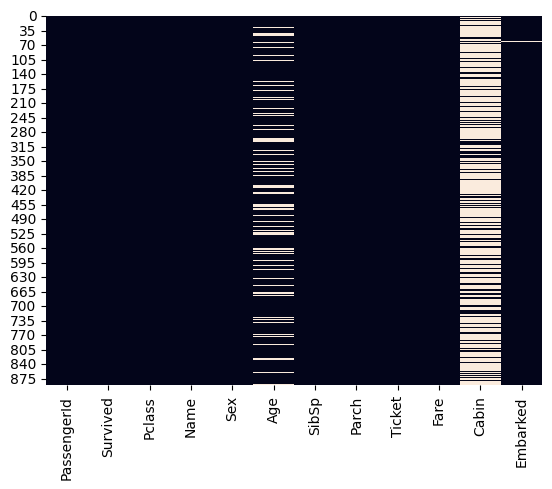

0
<StringArray>
['male', 'female']
Length: 2, dtype: str


/tmp/ipykernel_16156/3063817646.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('../data/train.csv')
print(df.info())  # Shows missing: Age 177, Cabin 687, Embarked 2
print(df.describe())  # For outliers: Fare max 512, Age max 80

# Missing values visualization
sns.heatmap(df.isnull(), cbar=False)
plt.show()

# Impute Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Impute Age with median by Pclass and Sex
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

# Cabin: Add indicator and drop
df['CabinMissing'] = df['Cabin'].isnull().astype(int)
df.drop('Cabin', axis=1, inplace=True)

# Outliers: Cap Fare
fare_cap = df['Fare'].quantile(0.99)  # 263
df['Fare'] = np.where(df['Fare'] > fare_cap, fare_cap, df['Fare'])

# Check duplicates
print(df.duplicated().sum())  # 0

# Consistency: Sex unique values
print(df['Sex'].unique())  # ['male' 'female']

# Save cleaned
df.to_csv('../data/train_cleaned.csv', index=False)